In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [49]:
df = pd.read_csv('AmesHousing.csv')

numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].abs().sort_values(ascending=False)

features = correlations.index[1:6].tolist()
print(f"Chosen features: {features}")
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape: {df.shape}')

Chosen features: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF']
Missing values: 15749
Dataset shape: (2930, 82)


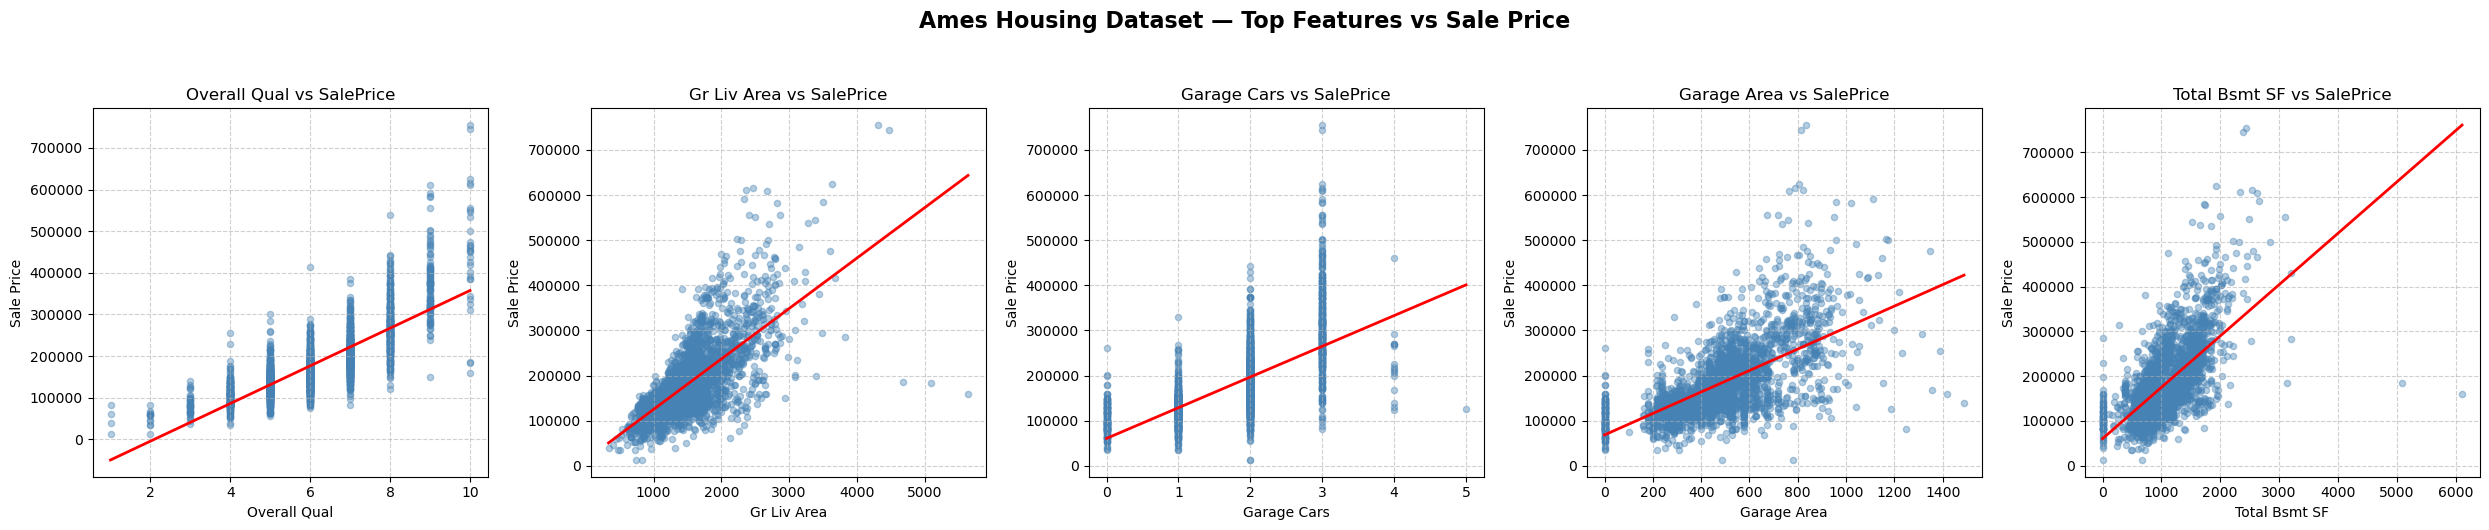

In [54]:
target = 'SalePrice'

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()

for i, feat in enumerate(features):
    valid_data = df[[feat, target]].dropna()
    x_val = valid_data[feat]
    y_val = valid_data[target]
    
    axes[i].scatter(x_val, y_val, alpha=0.4, s=20, color='steelblue')
    
 
    m, b = np.polyfit(x_val, y_val, 1)
    x_line = np.linspace(x_val.min(), x_val.max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r-', lw=2)
    
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('Sale Price', fontsize=10)
    axes[i].set_title(f'{feat} vs SalePrice', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Ames Housing Dataset — Top Features vs Sale Price', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [55]:
X = df[features].values
y = df['SalePrice'].values

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train shape : {X_train_s.shape}')
print(f'Val shape   : {X_val_s.shape}')
print(f'Test shape  : {X_test_s.shape}')

Train shape : (2050, 5)
Val shape   : (440, 5)
Test shape  : (440, 5)


In [70]:
def ols_fit(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])  
    w_star = np.linalg.pinv(X_b.T @ X_b) @ (X_b.T @ y)
    return w_star

def ols_predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])

    return X_b @ w

w_ols = ols_fit(X_train_s, y_train)

print('OLS Weights (intercept + feature coefficients) for Ames Housing:')
print(f'  Intercept : {w_ols[0]:.4f}')

for name, coef in zip(features, w_ols[1:]):
    print(f'  {name:<15} : {coef:.4f}')

OLS Weights (intercept + feature coefficients) for Ames Housing:
  Intercept : 178552.3541
  Overall Qual    : 34702.5620
  Gr Liv Area     : 20144.5203
  Garage Cars     : 10043.7123
  Garage Area     : 3639.9772
  Total Bsmt SF   : 13420.0538


In [ ]:
y_pred_ols = ols_predict(X_test_s, w_ols)

In [71]:
sk_model = LinearRegression()
sk_model.fit(X_train_s, y_train)

print('sklearn Weights:')
print(f'  Intercept : {sk_model.intercept_:.4f}')

for name, coef in zip(features, sk_model.coef_):
    print(f'  {name:<15} : {coef:.4f}')

max_diff = np.max(np.abs(w_ols[1:] - sk_model.coef_))
intercept_diff = np.abs(w_ols[0] - sk_model.intercept_)

print(f'\nMax coefficient difference (OLS vs sklearn): {max_diff:.2e}')
print('→ OLS and sklearn produce IDENTICAL results✓')

sklearn Weights:
  Intercept : 178552.3541
  Overall Qual    : 34702.5620
  Gr Liv Area     : 20144.5203
  Garage Cars     : 10043.7123
  Garage Area     : 3639.9772
  Total Bsmt SF   : 13420.0538

Max coefficient difference (OLS vs sklearn): 3.58e-10
→ OLS and sklearn produce IDENTICAL results✓


In [83]:
def evaluate(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:<25}  MSE={mse:>12.2f}  RMSE={rmse:>9.2f}  R²={r2:.4f}')
    return mse, rmse, r2

y_val_ols  = ols_predict(X_val_s,  w_ols)
y_val_sk   = sk_model.predict(X_val_s)

y_test_ols = ols_predict(X_test_s, w_ols)
y_test_sk  = sk_model.predict(X_test_s)

print('─'*75)
print(f'{"Method":<25}  {"MSE":>12}  {"RMSE":>9}  {"R²"}')
print('─'*75)
mse_ov,  rmse_ov,  r2_ov  = evaluate(y_val,  y_val_ols,  'OLS — Validation')
mse_sv,  rmse_sv,  r2_sv  = evaluate(y_val,  y_val_sk,   'sklearn — Validation')
print('─'*75)
mse_ot,  rmse_ot,  r2_ot  = evaluate(y_test, y_test_ols, 'OLS — Test')
mse_st,  rmse_st,  r2_st  = evaluate(y_test, y_test_sk,  'sklearn — Test')
print('─'*75)

───────────────────────────────────────────────────────────────────────────
Method                              MSE       RMSE  R²
───────────────────────────────────────────────────────────────────────────
OLS — Validation           MSE=1589850298.68  RMSE= 39872.93  R²=0.7950
sklearn — Validation       MSE=1589850298.68  RMSE= 39872.93  R²=0.7950
───────────────────────────────────────────────────────────────────────────
OLS — Test                 MSE=1602821989.34  RMSE= 40035.26  R²=0.7914
sklearn — Test             MSE=1602821989.34  RMSE= 40035.26  R²=0.7914
───────────────────────────────────────────────────────────────────────────


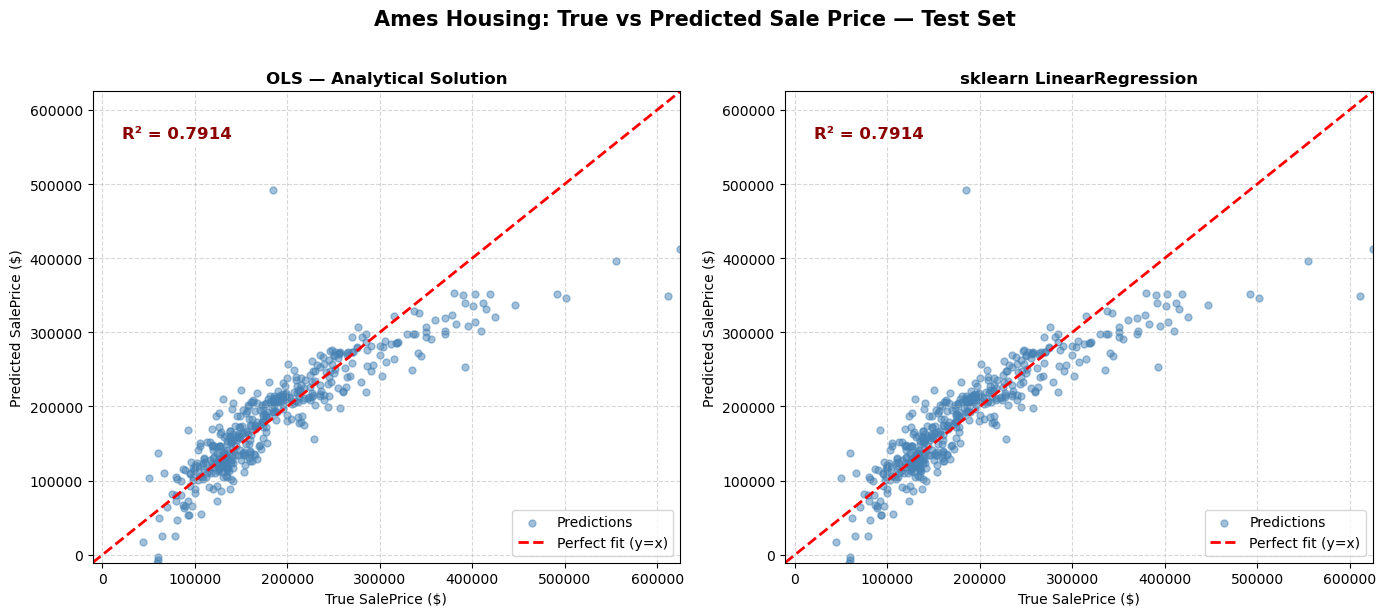

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = [
    (y_test_ols, 'OLS — Analytical Solution', r2_ot),
    (y_test_sk, 'sklearn LinearRegression', r2_st)
]

for i, (y_pred, title, r2) in enumerate(methods):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, s=25, color='steelblue', label='Predictions')
    
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    lims = [mn, mx]
    
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit (y=x)')
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('True SalePrice ($)', fontsize=10)
    ax.set_ylabel('Predicted SalePrice ($)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    
    ax.text(0.05, 0.90, f'R² = {r2:.4f}', transform=ax.transAxes, 
            fontsize=12, color='darkred', fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Ames Housing: True vs Predicted Sale Price — Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

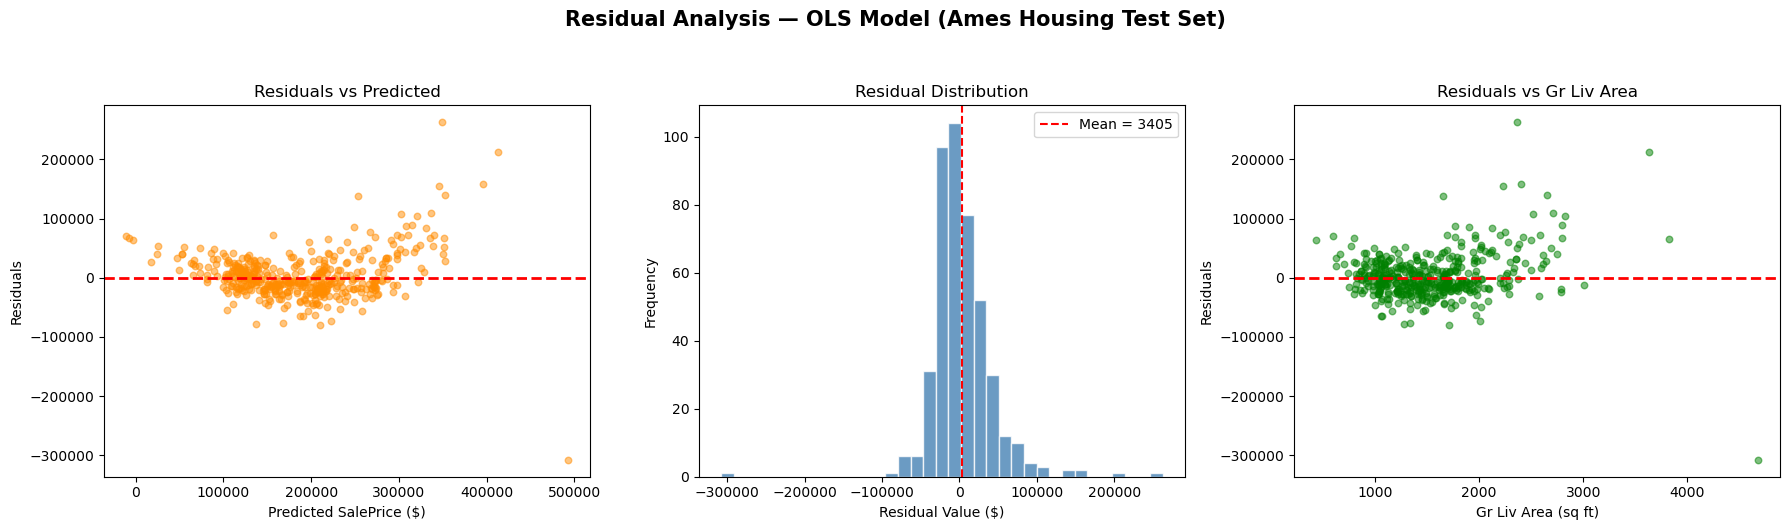

Residual stats — mean: 3404.715, std: 39890.223
Min: -307792.4, Max: 262828.9


In [74]:

residuals = y_test - y_test_ols

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_ols, residuals, alpha=0.5, s=22, color='darkorange')
axes[0].axhline(0, color='red', lw=2, ls='--')
axes[0].set_xlabel('Predicted SalePrice ($)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(residuals.mean(), color='red', ls='--', lw=1.5, label=f'Mean = {residuals.mean():.0f}')
axes[1].set_xlabel('Residual Value ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()

feat_idx = features.index('Gr Liv Area')
axes[2].scatter(X_test[:, feat_idx], residuals, alpha=0.5, s=22, color='green')
axes[2].axhline(0, color='red', lw=2, ls='--')
axes[2].set_xlabel('Gr Liv Area (sq ft)')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Gr Liv Area')

plt.suptitle('Residual Analysis — OLS Model (Ames Housing Test Set)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f'Residual stats — mean: {residuals.mean():.3f}, std: {residuals.std():.3f}')
print(f'Min: {residuals.min():.1f}, Max: {residuals.max():.1f}')

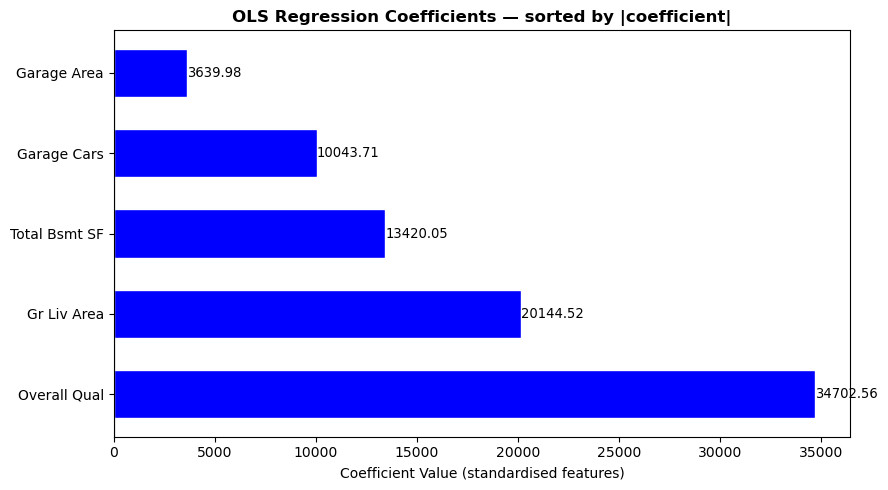

In [80]:
coef_vals = w_ols[1:]
sorted_idx = np.argsort(np.abs(coef_vals))[::-1]
sorted_feats = [features[i] for i in sorted_idx]
sorted_coefs = coef_vals[sorted_idx]

colors = ['red' if c < 0 else 'blue' for c in sorted_coefs]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh( sorted_feats,sorted_coefs,color=colors,edgecolor='white',height=0.6)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient Value (standardised features)')
ax.set_title(
    'OLS Regression Coefficients — sorted by |coefficient|',
    fontweight='bold'
)

for bar, val in zip(bars, sorted_coefs):
    offset = 0.5 if val >= 0 else -0.5
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=9.5
    )

plt.tight_layout()
plt.show()

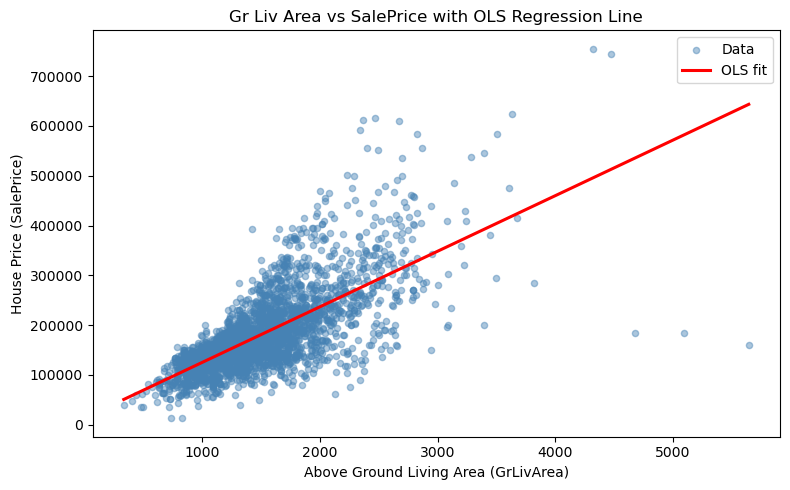

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df['Gr Liv Area'],
    df['SalePrice'],
    alpha=0.45,
    s=20,
    color='steelblue',
    label='Data'
)

x_line = np.linspace(df['Gr Liv Area'].min(), df['Gr Liv Area'].max(), 200)
m, b = np.polyfit(df['Gr Liv Area'], df['SalePrice'], 1)

ax.plot(
    x_line,
    m * x_line + b,
    'r-',
    lw=2.2,
    label='OLS fit'
)

ax.set_xlabel('Above Ground Living Area (GrLivArea)')
ax.set_ylabel('House Price (SalePrice)')
ax.set_title('Gr Liv Area vs SalePrice with OLS Regression Line')

ax.legend()
plt.tight_layout()
plt.show()

In [35]:
print('COEFFICIENT INTERPRETATION (on standardised features)')
print('=' * 60)
print(f'Intercept: {w_ols[0]:.2f} → baseline house price prediction (mean of y_train)')
print()

for name, coef in zip(features, w_ols[1:]):
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(
        f'{name:>15}: {coef:>8.2f}  → 1 SD increase in {name} {direction} '
        f'house price by {abs(coef):.2f} units'
    )

COEFFICIENT INTERPRETATION (on standardised features)
Intercept: 178552.35 → baseline house price prediction (mean of y_train)

   Overall Qual: 34702.56  → 1 SD increase in Overall Qual INCREASES house price by 34702.56 units
    Gr Liv Area: 20144.52  → 1 SD increase in Gr Liv Area INCREASES house price by 20144.52 units
    Garage Cars: 10043.71  → 1 SD increase in Garage Cars INCREASES house price by 10043.71 units
    Garage Area:  3639.98  → 1 SD increase in Garage Area INCREASES house price by 3639.98 units
  Total Bsmt SF: 13420.05  → 1 SD increase in Total Bsmt SF INCREASES house price by 13420.05 units


In [84]:
joblib.dump(
    {
        'model': sk_model,
        'scaler': scaler,
        'ols_weights': w_ols,
        'feature_names': features    
    },
    'ames_housing_linear_regression.joblib')

loaded = joblib.load('ames_housing_linear_regression.joblib')
test_pred = loaded['model'].predict(X_test_s[:3])

print('Model saved and verified. Sample predictions:', test_pred.round(2))

Model saved and verified. Sample predictions: [205739.68 127596.69 209282.16]
